Wybrano próbkę: Sklep CA_1, kategoria HOBBIES. Liczba unikalnych produktów: 565
Całkowita liczba rekordów (dni x produkty): 1080845
Liczba dni z zerową sprzedażą: 786335
PROCENT ZEROWEJ SPRZEDAŻY: 72.75%


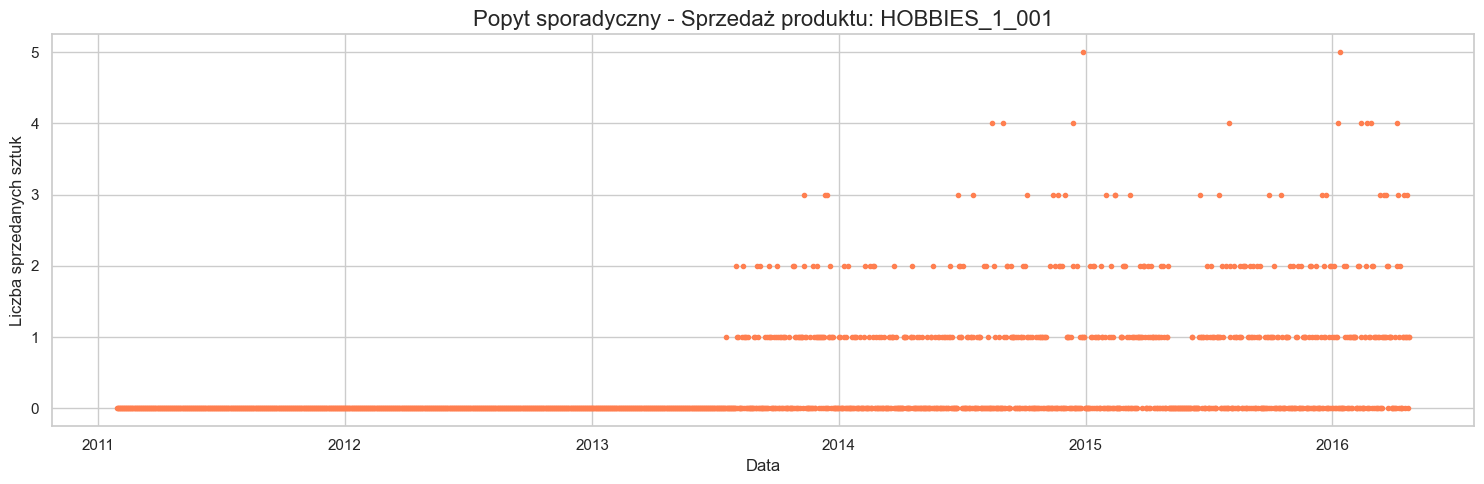

C:\Users\kpapr\AppData\Local\Temp\ipykernel_16632\1977151488.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='snap_CA', y='Sales', data=df, palette="muted")


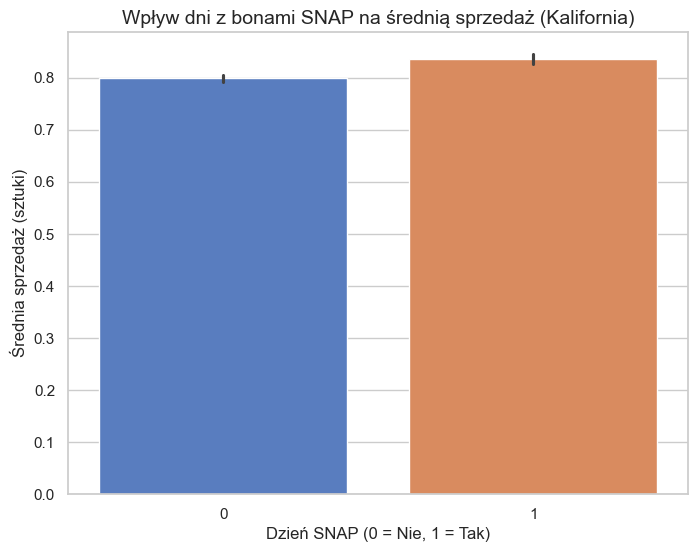

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sales_raw = pd.read_csv('sales_train_validation.csv')
calendar = pd.read_csv('calendar.csv')

sales_subset = sales_raw[(sales_raw['store_id'] == 'CA_1') & (sales_raw['cat_id'] == 'HOBBIES')].copy()

print(f"Wybrano próbkę: Sklep CA_1, kategoria HOBBIES. Liczba unikalnych produktów: {len(sales_subset)}")

id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_melted = pd.melt(sales_subset, id_vars=id_vars, var_name='d', value_name='Sales')

df = pd.merge(df_melted, calendar, on='d', how='left')

#sortowanie
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['item_id', 'date']).reset_index(drop=True)

#popyt sporadyczny
zero_sales_count = (df['Sales'] == 0).sum()
total_rows = len(df)
zero_sales_percentage = (zero_sales_count / total_rows) * 100

print(f"Całkowita liczba rekordów (dni x produkty): {total_rows}")
print(f"Liczba dni z zerową sprzedażą: {zero_sales_count}")
print(f"PROCENT ZEROWEJ SPRZEDAŻY: {zero_sales_percentage:.2f}%")


sample_item = df['item_id'].unique()[0]
single_item_data = df[df['item_id'] == sample_item]

plt.figure(figsize=(15, 5))
plt.plot(single_item_data['date'], single_item_data['Sales'], color='coral', marker='o', linestyle='', markersize=3)
plt.title(f'Popyt sporadyczny - Sprzedaż produktu: {sample_item}', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Liczba sprzedanych sztuk', fontsize=12)
plt.tight_layout()
plt.savefig('popyt sporadyczny.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='snap_CA', y='Sales', data=df, palette="muted")
plt.title('Wpływ dni z bonami SNAP na średnią sprzedaż (Kalifornia)', fontsize=14)
plt.xlabel('Dzień SNAP (0 = Nie, 1 = Tak)')
plt.ylabel('Średnia sprzedaż (sztuki)')
plt.savefig('wplyw_dni.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df['Has_Event'] = df['event_name_1'].notnull().astype(int)

df['Sales_Lag_7'] = df.groupby('item_id')['Sales'].shift(7)
df['Sales_Lag_28'] = df.groupby('item_id')['Sales'].shift(28)

df['Sales_Rolling_Mean_7'] = df.groupby('item_id')['Sales'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

df.dropna(subset=['Sales_Lag_28', 'Sales_Rolling_Mean_7'], inplace=True)

features_to_keep = ['wday', 'month', 'year', 'snap_CA', 'Has_Event', 
                    'Sales_Lag_7', 'Sales_Lag_28', 'Sales_Rolling_Mean_7']

X = df[features_to_keep]
y = df['Sales']

X = X.fillna(0)

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Dane Treningowe (Walmart): {len(X_train)} próbek")
print(f"Dane Testowe (Walmart): {len(X_test)} próbek\n")

results_walmart = []


def calculate_wmape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-5)) * 100

# REGRESJA LINIOWA
lr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)


lr_preds = np.maximum(lr_pipeline.predict(X_test), 0) 

results_walmart.append({
    'Model': 'Regresja Liniowa (Baseline)',
    'MAE': mean_absolute_error(y_test, lr_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_preds)),
    'WMAPE (%)': calculate_wmape(y_test, lr_preds)
})

# RANDOM FOREST
rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)


rf_preds = np.maximum(rf.predict(X_test), 0)

results_walmart.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, rf_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_preds)),
    'WMAPE (%)': calculate_wmape(y_test, rf_preds)
})

# XGBOOST
tscv = TimeSeriesSplit(n_splits=3)

xgb_pipeline = Pipeline(steps=[
    ('model', XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42))
])


param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)


best_xgb = grid_search.best_estimator_
xgb_preds = np.maximum(best_xgb.predict(X_test), 0)

results_walmart.append({
    'Model': 'XGBoost (GridSearch)',
    'MAE': mean_absolute_error(y_test, xgb_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_preds)),
    'WMAPE (%)': calculate_wmape(y_test, xgb_preds)
})



results_df_walmart = pd.DataFrame(results_walmart).round(2)
display(results_df_walmart)


y_pred = xgb_preds
xgb_model = best_xgb.named_steps['model']

Dane Treningowe (Walmart): 852020 próbek
Dane Testowe (Walmart): 213005 próbek

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,Model,MAE,RMSE,WMAPE (%)
0,Regresja Liniowa (Baseline),0.39,0.79,198.39
1,Random Forest,0.34,0.80,175.95
2,XGBoost (GridSearch),0.34,0.79,175.76


In [3]:
import numpy as np

# Zabezpieczenie typu danych
y_test_array = np.array(y_test)
xgb_preds_array = np.array(xgb_preds)

n_bootstraps = 1000
wmape_scores = []

# Symulacja Bootstrapping (1000 iteracji)
np.random.seed(42)
for i in range(n_bootstraps):
    # Losowanie ze zwracaniem
    indices = np.random.choice(len(y_test_array), len(y_test_array), replace=True)
    y_true_b = y_test_array[indices]
    y_pred_b = xgb_preds_array[indices]
    
    # Obliczanie WMAPE dla danej próbki
    wmape = (np.sum(np.abs(y_true_b - y_pred_b)) / np.sum(np.abs(y_true_b))) * 100
    wmape_scores.append(wmape)

# Obliczenie 95% przedziału ufności
lower_bound = np.percentile(wmape_scores, 2.5)
upper_bound = np.percentile(wmape_scores, 97.5)

print(f"Błąd WMAPE (XGBoost Walmart): {calculate_wmape(y_test, xgb_preds):.2f}%")
print(f"95% Przedział Ufności (Bootstrapping): [{lower_bound:.2f}%, {upper_bound:.2f}%]")

Błąd WMAPE (XGBoost Walmart): 175.76%
95% Przedział Ufności (Bootstrapping): [173.73%, 177.63%]


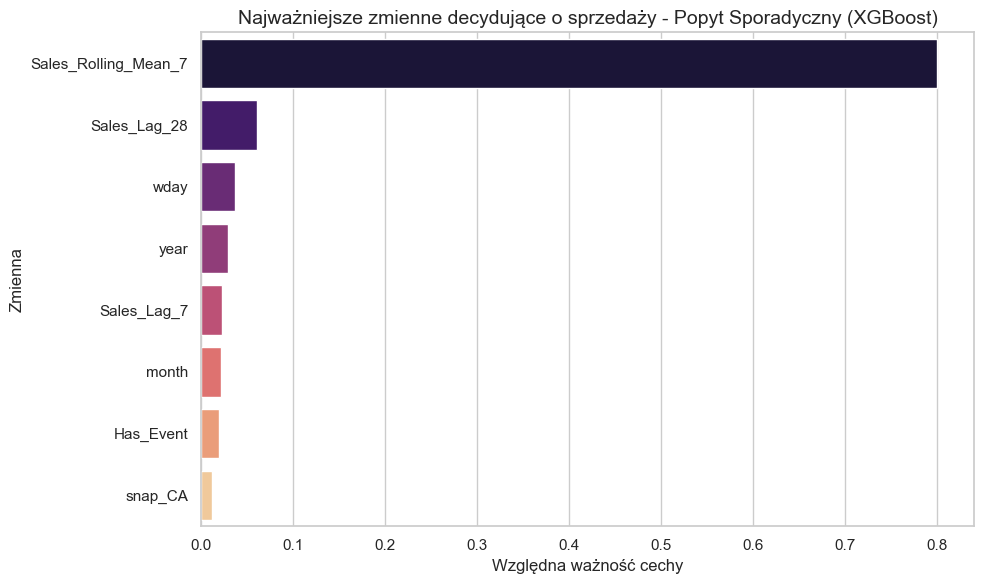

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

actual_model = best_xgb.named_steps['model']
importances_walmart = actual_model.feature_importances_

feature_importance_df_walmart = pd.DataFrame({
    'Cecha': X.columns,
    'Ważność': importances_walmart
})

top_features_w = feature_importance_df_walmart.sort_values(by='Ważność', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Ważność', 
    y='Cecha', 
    data=top_features_w, 
    palette='magma',
    hue='Cecha',
    legend=False
)

plt.title('Najważniejsze zmienne decydujące o sprzedaży - Popyt Sporadyczny (XGBoost)', fontsize=14)
plt.xlabel('Względna ważność cechy', fontsize=12)
plt.ylabel('Zmienna', fontsize=12)
plt.tight_layout()


nazwa_pliku_wykresu = 'Wykres_Waznosc_Cech_Walmart.png'
plt.savefig(nazwa_pliku_wykresu, dpi=300, bbox_inches='tight')


plt.show()